In [28]:
import pandas as pd
import numpy as np
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import confusion_matrix, classification_report, roc_auc_score, average_precision_score, roc_curve, precision_recall_curve, precision_score, recall_score, f1_score
import matplotlib.pyplot as plt
from sklearn.ensemble import RandomForestClassifier, HistGradientBoostingClassifier
import joblib

In [2]:
df = pd.read_csv("data/loan_data_cleaned_eda.csv")
df.shape

(1305564, 181)

In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1305564 entries, 0 to 1305563
Columns: 181 entries, loan_amnt to target
dtypes: float64(53), int64(128)
memory usage: 1.8 GB


In [4]:
X = df.drop(columns=["target"])
y = df["target"]

print("X shape:", X.shape)
print("y shape:", y.shape)

X shape: (1305564, 180)
y shape: (1305564,)


In [5]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

print("X_train:", X_train.shape)
print("X_test:", X_test.shape)
print("y_train:", y_train.shape)
print("y_test:", y_test.shape)

X_train: (1044451, 180)
X_test: (261113, 180)
y_train: (1044451,)
y_test: (261113,)


In [6]:
categorical_features = X_train.select_dtypes(include=["object", "category"]).columns

numerical_features = X_train.select_dtypes(include=[np.number]).columns

print("Categorical:", len(categorical_features))
print("Numeerical:", len(numerical_features))

Categorical: 0
Numeerical: 180


In [7]:
X_train.describe().T[["mean", "std", "min", "max"]]

,mean,std,min,max
loan_amnt,14520.364096,8738.569745,1000.00,40000.00
int_rate,13.274478,4.791342,5.31,30.99
installment,441.614726,262.292385,4.93,1719.83
emp_length,5.998008,3.579085,0.00,10.00
annual_inc,75940.832559,49281.703707,0.00,600000.00
...,...,...,...,...
addr_state_WV,0.003578,0.059709,0.00,1.00
addr_state_WY,0.002186,0.046702,0.00,1.00
initial_list_status_w,0.600894,0.489715,0.00,1.00
application_type_Joint App,0.019843,0.139461,0.00,1.00


Identify continuous features

In [8]:
continuous_features = [
    col for col in X_train.columns
    if X_train[col].nunique() > 2
]

print("Number of continuous features:", len(continuous_features))
print(continuous_features)

Number of continuous features: 55
['loan_amnt', 'int_rate', 'installment', 'emp_length', 'annual_inc', 'dti', 'delinq_2yrs', 'inq_last_6mths', 'open_acc', 'pub_rec', 'revol_bal', 'revol_util', 'total_acc', 'collections_12_mths_ex_med', 'acc_now_delinq', 'tot_coll_amt', 'tot_cur_bal', 'total_rev_hi_lim', 'acc_open_past_24mths', 'avg_cur_bal', 'bc_open_to_buy', 'bc_util', 'chargeoff_within_12_mths', 'delinq_amnt', 'mo_sin_old_il_acct', 'mo_sin_old_rev_tl_op', 'mo_sin_rcnt_rev_tl_op', 'mo_sin_rcnt_tl', 'mort_acc', 'mths_since_recent_bc', 'mths_since_recent_inq', 'num_accts_ever_120_pd', 'num_actv_bc_tl', 'num_actv_rev_tl', 'num_bc_sats', 'num_bc_tl', 'num_il_tl', 'num_op_rev_tl', 'num_rev_accts', 'num_tl_120dpd_2m', 'num_tl_30dpd', 'num_tl_90g_dpd_24m', 'num_tl_op_past_12m', 'pct_tl_nvr_dlq', 'percent_bc_gt_75', 'pub_rec_bankruptcies', 'tax_liens', 'tot_hi_cred_lim', 'total_bal_ex_mort', 'total_bc_limit', 'total_il_high_credit_limit', 'fico_score', 'issue_year', 'issue_month', 'credit_his

Scalling the continuous features

In [9]:
scaler = StandardScaler()

X_train[continuous_features] = scaler.fit_transform(X_train[continuous_features])

X_test[continuous_features] = scaler.transform(X_test[continuous_features])

In [10]:
X_train[continuous_features].describe().T[["mean", "std"]]

,mean,std
loan_amnt,-6.530905e-19,1.0
int_rate,-1.516258e-16,1.0
installment,-1.799264e-16,1.0
emp_length,-1.130391e-16,1.0
annual_inc,5.828833e-17,1.0
dti,-3.172931e-17,1.0
delinq_2yrs,4.408361e-17,1.0
inq_last_6mths,-1.708920e-17,1.0
open_acc,-8.136419e-17,1.0
pub_rec,7.129571e-17,1.0


Logistic Regression

In [10]:
model = LogisticRegression(
    class_weight="balanced",
    max_iter=1000,
    random_state=42
)

model.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,'balanced'
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [17]:
y_pred = model.predict(X_test)

print(y_pred[:20])

[0 1 1 1 0 1 1 0 0 0 1 1 1 1 0 1 0 0 0 0]


In [19]:
cm = confusion_matrix(y_test, y_pred)
print(cm)

[[134626  73901]
 [ 16850  35736]]


In [21]:
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           0       0.89      0.65      0.75    208527
           1       0.33      0.68      0.44     52586

    accuracy                           0.65    261113
   macro avg       0.61      0.66      0.59    261113
weighted avg       0.78      0.65      0.69    261113



Calculate ROC-AUC

In [23]:
y_prob = model.predict_proba(X_test)[:, 1]

print(y_prob[:10])

[0.16721379 0.53363324 0.54229447 0.72030947 0.37462812 0.73447729
 0.5618869  0.35732036 0.3013533  0.06618273]


In [25]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC:", roc_auc)

ROC-AUC: 0.7255592951220416


In [27]:
pr_auc = average_precision_score(y_test, y_prob)
print("PR-AUC:", pr_auc)

PR-AUC: 0.39934461176105474


ROC Curve

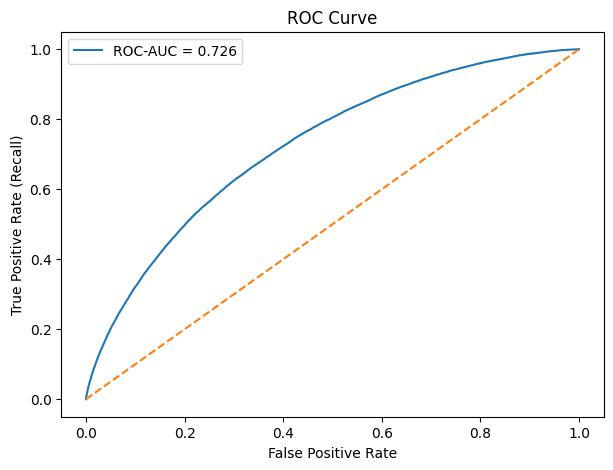

In [31]:
fpr, tpr, thresholds = roc_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f"ROC-AUC = {roc_auc:.3f}")
plt.plot([0, 1], [0, 1], linestyle="--")

plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate (Recall)")
plt.title("ROC Curve")
plt.legend()
plt.show()

Precision-Recall Curve

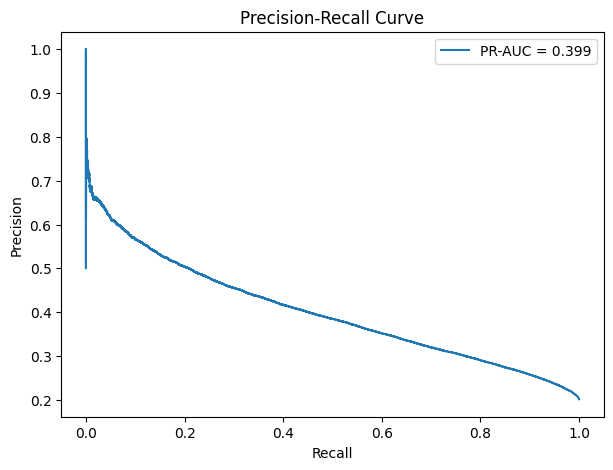

In [32]:
precision, recall, thresholds = precision_recall_curve(y_test, y_prob)

plt.figure(figsize=(7, 5))
plt.plot(recall, precision, label=f"PR-AUC = {pr_auc:.3f}")

plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")
plt.legend()
plt.show()

Random Forest Classifier

In [11]:
rf_model = RandomForestClassifier(
    n_estimators=100,
    class_weight="balanced",
    random_state=42,
    n_jobs=-1
)

rf_model.fit(X_train, y_train)

,n_estimators,100
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


In [12]:
rf_pred = rf_model.predict(X_test)

print(rf_pred.shape)

(261113,)


In [13]:
rf_cm = confusion_matrix(y_test, rf_pred)
print(rf_cm)

[[206499   2028]
 [ 49789   2797]]


In [14]:
print(classification_report(y_test, rf_pred))

              precision    recall  f1-score   support

           0       0.81      0.99      0.89    208527
           1       0.58      0.05      0.10     52586

    accuracy                           0.80    261113
   macro avg       0.69      0.52      0.49    261113
weighted avg       0.76      0.80      0.73    261113



Random Forest is predicting class 0, so it gets many class-0 examples correct.

In [15]:
rf_prob = rf_model.predict_proba(X_test)[:, 1]

print(rf_prob[:10])

[0.09 0.16 0.28 0.36 0.11 0.42 0.34 0.15 0.11 0.02]


Calculate ROC-AUC

In [16]:
rf_roc_auc = roc_auc_score(y_test, rf_prob)

print("Random Forest ROC-AUC:", rf_roc_auc)

Random Forest ROC-AUC: 0.7185502435208013


In [17]:
rf_pr_auc = average_precision_score(y_test, rf_prob)

print("Random Forest PR-AUC:", rf_pr_auc)

Random Forest PR-AUC: 0.3846718848498738


Gradient Boosting

In [11]:
gb_model = HistGradientBoostingClassifier(
    max_iter=100,
    learning_rate=0.1,
    max_leaf_nodes=31,
    class_weight="balanced",
    random_state=42
)

gb_model.fit(X_train, y_train)

,loss,'log_loss'
,learning_rate,0.1
,max_iter,100
,max_leaf_nodes,31
,max_depth,None
,min_samples_leaf,20
,l2_regularization,0.0
,max_features,1.0
,max_bins,255
,categorical_features,'from_dtype'
,monotonic_cst,None


In [12]:
gb_pred = gb_model.predict(X_test)

print(gb_pred.shape)
print(gb_pred[:20])

(261113,)
[0 1 1 1 0 1 1 0 0 0 1 1 1 1 0 1 0 1 0 0]


In [13]:
gb_cm = confusion_matrix(y_test, gb_pred)

print(gb_cm)

[[136411  72116]
 [ 16332  36254]]


In [14]:
print(classification_report(y_test, gb_pred))

              precision    recall  f1-score   support

           0       0.89      0.65      0.76    208527
           1       0.33      0.69      0.45     52586

    accuracy                           0.66    261113
   macro avg       0.61      0.67      0.60    261113
weighted avg       0.78      0.66      0.69    261113



Probability predictions

In [15]:
gb_prob = gb_model.predict_proba(X_test)[:, 1]

print(gb_prob[:10])

[0.04551072 0.51219786 0.55994242 0.70267947 0.30741032 0.75660318
 0.62474975 0.38743327 0.42821566 0.0696697 ]


Gradient Boosting ROC-AUC

In [16]:
gb_roc_auc = roc_auc_score(y_test, gb_prob)

print("Gradient Boosting ROC-AUC:", gb_roc_auc)

Gradient Boosting ROC-AUC: 0.7377588233714751


Gradient Boosting PR-AUC

In [17]:
gb_pr_auc = average_precision_score(y_test, gb_prob)

print("Gradient Boosting PR-AUC:", gb_pr_auc)

Gradient Boosting PR-AUC: 0.41951303388327843


Test several thresholds

In [18]:
thresholds = np.arange(0.40, 0.61, 0.01)

results = []

for threshold in thresholds:
    predictions = (gb_prob >= threshold).astype(int)

    results.append({
        "Threshold": threshold,
        "Precision": precision_score(y_test, predictions),
        "Recall": recall_score(y_test, predictions),
        "F1": f1_score(y_test, predictions)
    })

threshold_results = pd.DataFrame(results)
print(threshold_results.sort_values("F1", ascending=False).head(10))

    Threshold  Precision    Recall        F1
15       0.55   0.364092  0.604096  0.454347
14       0.54   0.357162  0.621078  0.453520
16       0.56   0.370287  0.584985  0.453509
13       0.53   0.351069  0.638668  0.453083
12       0.52   0.345454  0.656182  0.452621
17       0.57   0.376813  0.565778  0.452354
11       0.51   0.339965  0.673259  0.451795
18       0.58   0.383985  0.546952  0.451204
10       0.50   0.334539  0.689423  0.450483
9        0.49   0.329348  0.706119  0.449186


Visualization

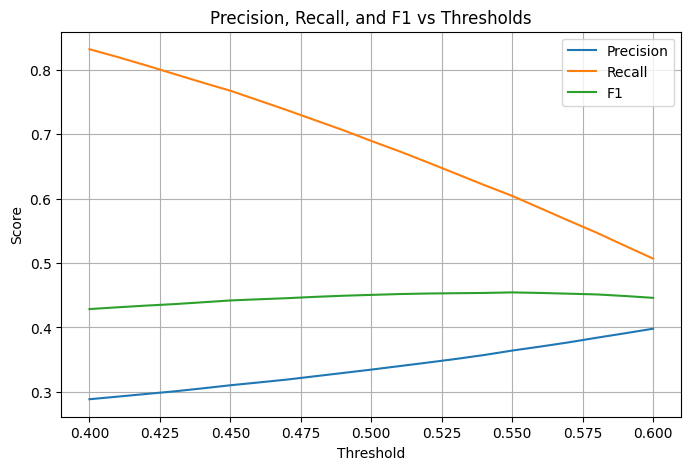

In [19]:
plt.figure(figsize=(8, 5))

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Precision"],
    label="Precision"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["Recall"],
    label="Recall"
)

plt.plot(
    threshold_results["Threshold"],
    threshold_results["F1"],
    label="F1"
)

plt.xlabel("Threshold")
plt.ylabel("Score")
plt.title("Precision, Recall, and F1 vs Thresholds")
plt.legend()
plt.grid()
plt.show()

In [20]:
best_threshold = threshold_results.loc[
    threshold_results["F1"].idxmax(), "Threshold"
]

print("Best threshold:", best_threshold)

Best threshold: 0.5500000000000002


Final Prediction using 0.55

In [21]:
final_pred = (gb_prob >= best_threshold).astype(int)

print(final_pred[:20])

[0 0 1 1 0 1 1 0 0 0 1 0 1 0 0 1 0 1 0 0]


Final confusion matrix

In [22]:
final_cm = confusion_matrix(y_test, final_pred)

print(final_cm)

[[153044  55483]
 [ 20819  31767]]


Final classification report

In [23]:
print(classification_report(y_test, final_pred))

              precision    recall  f1-score   support

           0       0.88      0.73      0.80    208527
           1       0.36      0.60      0.45     52586

    accuracy                           0.71    261113
   macro avg       0.62      0.67      0.63    261113
weighted avg       0.78      0.71      0.73    261113



Create the comparison table

In [24]:
model_comparison = pd.DataFrame({
    "Model": [
        "Logistic Regression",
        "Random Forest",
        "Gradient Boosting"
    ],
    "Accuracy": [
        0.65,
        0.80,
        0.66
    ],
    "Class 1 Precision": [
        0.33,
        0.58,
        0.33
    ],
    "Class 1 Recall": [
        0.68,
        0.05,
        0.69
    ],
    "Class 1 F1": [
        0.44,
        0.10,
        0.45
    ],
    "ROC-AUC": [
        0.7256,
        0.7186,
        0.7378
    ],
    "PR-AUC": [
        0.3993,
        0.3847,
        0.4195
    ]
})

model_comparison

,Model,Accuracy,Class 1 Precision,Class 1 Recall,Class 1 F1,ROC-AUC,PR-AUC
0,Logistic Regression,0.65,0.33,0.68,0.44,0.7256,0.3993
1,Random Forest,0.80,0.58,0.05,0.10,0.7186,0.3847
2,Gradient Boosting,0.66,0.33,0.69,0.45,0.7378,0.4195


The Final Gradient Boosting Evaluation after threshold tunning to 0.55

In [25]:
final_results = pd.DataFrame({
    "Metric": [
        "Threshold",
        "Accuracy",
        "Class 1 Precision",
        "Class 1 Recall",
        "Class 1 F1",
        "ROC-AUC",
        "PR-AUC"
    ],
    "Value": [
        best_threshold,
        0.71,
        0.36,
        0.60,
        0.45,
        gb_roc_auc,
        gb_pr_auc
    ]
})

final_results

,Metric,Value
0,Threshold,0.550000
1,Accuracy,0.710000
2,Class 1 Precision,0.360000
3,Class 1 Recall,0.600000
4,Class 1 F1,0.450000
5,ROC-AUC,0.737759
6,PR-AUC,0.419513


In [26]:
df.to_csv("data/final_trained_model.csv", index=False)

In [27]:
df.shape

(1305564, 181)

In [30]:
joblib.dump(gb_model, "models/gradient_boosting_model.pk1")

['models/gradient_boosting_model.pk1']

In [31]:
joblib.dump(scaler, "models/scaler.pk1")

['models/scaler.pk1']

In [32]:
joblib.dump(best_threshold, "models/threshold.pk1")

['models/threshold.pk1']